In [ ]:
# STEP 0 (Google Colab): run this cell, click "Choose files", and select Dataset.csv
import os
if not os.path.exists("Dataset.csv"):
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        print("Not in Colab: place Dataset.csv next to this notebook.")
print("Dataset found:", os.path.exists("Dataset.csv"))

Dataset found: True


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

pd.set_option("display.max_colwidth", 80)
df = pd.read_csv("Dataset.csv")   # keep Dataset.csv in the same folder as this notebook
print(df.shape)
df.head()

(8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure"
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
# Data quality check
print("Duplicate titles:", df["title"].duplicated().sum())
print("director == 'Not Given':", (df["director"] == "Not Given").sum())
print("country  == 'Not Given':", (df["country"] == "Not Given").sum())
print("Missing values:\n", df.isna().sum())

Duplicate titles: 3
director == 'Not Given': 2588
country  == 'Not Given': 287
Missing values:
 show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


The dataset has no true missing values, but `director` and `country` use the placeholder text **"Not Given"**. If we left it in, every title with no director would look "similar" to every other one, so we remove it.

In [ ]:
# Remove duplicate titles and reset the index so row numbers match the similarity matrix
df = df.drop_duplicates(subset="title").reset_index(drop=True)

def to_tokens(text):
    """'Raul Campos, Jan Suter' -> ['raul_campos', 'jan_suter'].
    Multi-word names become ONE token so 'Jan' alone never matches 'Jan'."""
    if pd.isna(text) or text.strip() in ("", "Not Given"):
        return []
    return [t.strip().lower().replace(" ", "_").replace("&", "and")
            for t in text.split(",") if t.strip()]

df["genre_list"]    = df["listed_in"].apply(to_tokens)
df["director_list"] = df["director"].apply(to_tokens)
df["country_list"]  = df["country"].apply(to_tokens)

# Combine everything into one "content soup" per title.
# Genres are repeated so they count more than director/country.
def build_soup(row):
    tokens = (row["genre_list"] * 3
              + row["director_list"] * 1
              + row["country_list"] * 1
              + [row["type"].lower().replace(" ", "_")]
              + [("rating_" + row["rating"].lower())])
    return " ".join(tokens)

df["soup"] = df.apply(build_soup, axis=1)
df[["title", "soup"]].head(3)

,title,soup
0,Dick Johnson Is Dead,documentaries documentaries documentaries kirsten_johnson united_states movi...
1,Ganglands,crime_tv_shows international_tv_shows tv_action_and_adventure crime_tv_shows...
2,Midnight Mass,tv_dramas tv_horror tv_mysteries tv_dramas tv_horror tv_mysteries tv_dramas ...


In [ ]:
tfidf = TfidfVectorizer(dtype=np.float32)
tfidf_matrix = tfidf.fit_transform(df["soup"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size    :", len(tfidf.vocabulary_))

TF-IDF matrix shape: (8787, 5407)
Vocabulary size    : 5407


In [ ]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

# Lookup table: title -> row index
title_to_idx = pd.Series(df.index, index=df["title"].str.lower())

Similarity matrix shape: (8787, 8787)


In [ ]:
def recommend(title, n=10):
    """Return the n most similar titles to `title`."""
    key = title.lower().strip()
    if key not in title_to_idx:
        # helpful fallback: suggest close matches instead of crashing
        matches = df[df["title"].str.lower().str.contains(key, regex=False)]["title"].head(5).tolist()
        raise KeyError(f"'{title}' not found. Did you mean one of: {matches}")
    idx = title_to_idx[key]
    scores = cosine_sim[idx].copy()
    scores[idx] = -1                       # exclude the title itself
    top = np.argsort(scores)[::-1][:n]
    out = df.iloc[top][["title", "type", "listed_in", "country", "rating"]].copy()
    out.insert(1, "similarity", scores[top].round(3))
    return out.reset_index(drop=True)

print("Because you watched: Ganglands")
recommend("Ganglands", 10)

Because you watched: Ganglands


,title,similarity,type,listed_in,country,rating
0,Lupin,0.928,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",France,TV-MA
1,Crime Time,0.928,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",France,TV-MA
2,Fatal Destiny,0.889,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Pakistan,TV-MA
3,Agent Raghav,0.886,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",India,TV-14
4,Smoking,0.885,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Japan,TV-MA
5,The Truth,0.879,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Pakistan,TV-14
6,The Eagle of El-Se'eed,0.879,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Pakistan,TV-14
7,Monkey Twins,0.872,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Thailand,TV-MA
8,Filinta,0.868,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Turkey,TV-14
9,Kaçak,0.868,TV Show,"Crime TV Shows, International TV Shows, TV Action & Adventure",Turkey,TV-14


In [ ]:
print("Because you watched: The Great British Baking Show")
recommend("The Great British Baking Show", 10)

Because you watched: The Great British Baking Show


,title,similarity,type,listed_in,country,rating
0,Operation Gold Rush,0.905,TV Show,"British TV Shows, Reality TV",United Kingdom,TV-14
1,21 Again,0.893,TV Show,"British TV Shows, Reality TV",United Kingdom,TV-MA
2,The Repair Shop,0.885,TV Show,"British TV Shows, Reality TV",United Kingdom,TV-PG
3,The Big Catch,0.885,TV Show,"British TV Shows, Reality TV",United Kingdom,TV-PG
4,The Great British Baking Show: Masterclass,0.885,TV Show,"British TV Shows, Reality TV",United Kingdom,TV-PG
5,Diva Brides,0.860,TV Show,"British TV Shows, Reality TV",Pakistan,TV-MA
6,The Great British Baking Show: Holidays,0.860,TV Show,"British TV Shows, Reality TV",Pakistan,TV-MA
7,The Great British Baking Show: The Beginnings,0.852,TV Show,"British TV Shows, Reality TV",Pakistan,TV-PG
8,Kitten Rescuers,0.830,TV Show,"British TV Shows, International TV Shows, Reality TV",United Kingdom,TV-14
9,Glow Up,0.830,TV Show,"British TV Shows, International TV Shows, Reality TV",United Kingdom,TV-14


In [ ]:
print("Because you watched: Motu Patlu in Wonderland")
recommend("Motu Patlu in Wonderland", 10)

Because you watched: Motu Patlu in Wonderland


,title,similarity,type,listed_in,country,rating
0,Motu Patlu Kung Fu Kings 4 The Challenge of Kung Fu Brothers,1.000,Movie,"Children & Family Movies, Music & Musicals",India,TV-Y7
1,Motu Patlu in Hong Kong: Kung Fu Kings 3,1.000,Movie,"Children & Family Movies, Music & Musicals",India,TV-Y7
2,Motu Patlu in the City of Gold,0.921,Movie,"Children & Family Movies, Comedies, Music & Musicals",India,TV-Y7
3,Motu Patlu in the Game of Zones,0.921,Movie,"Children & Family Movies, Comedies, Music & Musicals",India,TV-Y7
4,"Monster High: Boo York, Boo York",0.816,Movie,"Children & Family Movies, Music & Musicals",United States,TV-Y7
5,DreamWorks Home: For the Holidays,0.789,Movie,"Children & Family Movies, Comedies, Music & Musicals",United States,TV-Y
6,Mariah Carey's Merriest Christmas,0.770,Movie,"Children & Family Movies, Music & Musicals",United States,TV-G
7,Mary Poppins Returns,0.755,Movie,"Children & Family Movies, Music & Musicals",United States,PG
8,Shiva VS Autobots,0.752,Movie,Children & Family Movies,India,TV-Y7
9,Motu Patlu the Superheroes – Super Villains from Mars,0.752,Movie,Children & Family Movies,India,TV-Y7


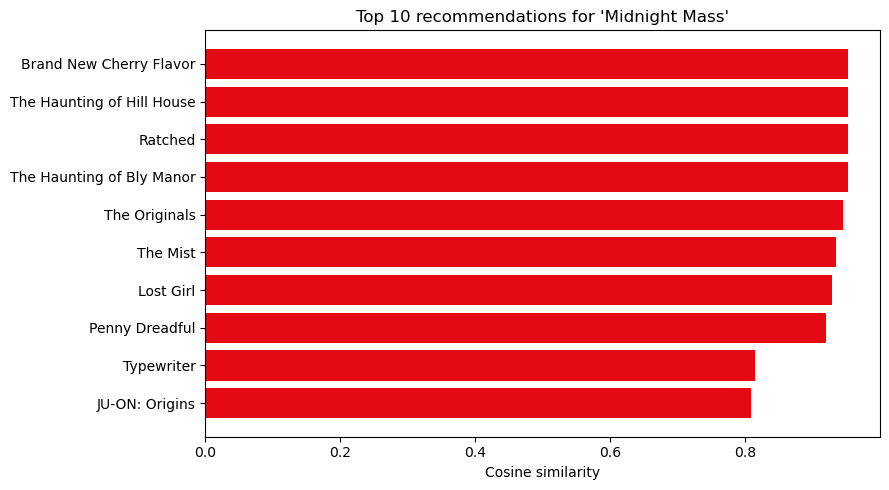

In [ ]:
# Visualise the similarity scores for one title
rec = recommend("Midnight Mass", 10)
plt.figure(figsize=(9, 5))
plt.barh(rec["title"][::-1], rec["similarity"][::-1], color="#e50914")
plt.xlabel("Cosine similarity")
plt.title("Top 10 recommendations for 'Midnight Mass'")
plt.tight_layout()
plt.show()

In [ ]:
def recommend_for_user(watched, n=10):
    idxs = [title_to_idx[t.lower()] for t in watched]
    scores = cosine_sim[idxs].mean(axis=0)
    scores[idxs] = -1                      # do not recommend what they already watched
    top = np.argsort(scores)[::-1][:n]
    out = df.iloc[top][["title", "type", "listed_in"]].copy()
    out.insert(1, "score", scores[top].round(3))
    return out.reset_index(drop=True)

history = ["Ganglands", "Midnight Mass", "Dick Johnson Is Dead"]
print("Watch history:", history)
recommend_for_user(history, 10)

Watch history: ['Ganglands', 'Midnight Mass', 'Dick Johnson Is Dead']


,title,score,type,listed_in
0,Scream,0.345,TV Show,"Crime TV Shows, TV Horror, TV Mysteries"
1,October Faction,0.334,TV Show,"TV Action & Adventure, TV Dramas, TV Horror"
2,V Wars,0.334,TV Show,"TV Action & Adventure, TV Dramas, TV Horror"
3,Betaal,0.327,TV Show,"International TV Shows, TV Action & Adventure, TV Horror"
4,The Haunting of Bly Manor,0.326,TV Show,"TV Dramas, TV Horror, TV Mysteries"
5,Brand New Cherry Flavor,0.326,TV Show,"TV Dramas, TV Horror, TV Mysteries"
6,Ratched,0.326,TV Show,"TV Dramas, TV Horror, TV Mysteries"
7,The Haunting of Hill House,0.326,TV Show,"TV Dramas, TV Horror, TV Mysteries"
8,Black Summer,0.325,TV Show,"TV Action & Adventure, TV Dramas, TV Horror"
9,The Originals,0.322,TV Show,"TV Dramas, TV Horror, TV Mysteries"


In [ ]:
rng = np.random.default_rng(42)
genre_sets = df["genre_list"].apply(set).tolist()
types = df["type"].values
K = 10

def evaluate(sample_idx, method="model"):
    prec, jac, same = [], [], []
    for i in sample_idx:
        if method == "model":
            s = cosine_sim[i].copy(); s[i] = -1
            top = np.argsort(s)[::-1][:K]
        else:
            top = rng.choice([j for j in range(len(df)) if j != i], K, replace=False)
        g = genre_sets[i]
        overlaps = [len(g & genre_sets[j]) for j in top]
        unions   = [len(g | genre_sets[j]) for j in top]
        prec.append(np.mean([o > 0 for o in overlaps]))
        jac.append(np.mean([o / u if u else 0 for o, u in zip(overlaps, unions)]))
        same.append(np.mean(types[top] == types[i]))
    return np.mean(prec), np.mean(jac), np.mean(same)

sample = rng.choice(len(df), 1000, replace=False)   # 1000 random titles
res = pd.DataFrame(
    {"Content-based model": evaluate(sample, "model"),
     "Random baseline":     evaluate(sample, "random")},
    index=["Genre precision@10", "Mean genre Jaccard", "Same-type rate"]).round(3)
res

,Content-based model,Random baseline
Genre precision@10,1.000,0.240
Mean genre Jaccard,0.943,0.093
Same-type rate,1.000,0.583


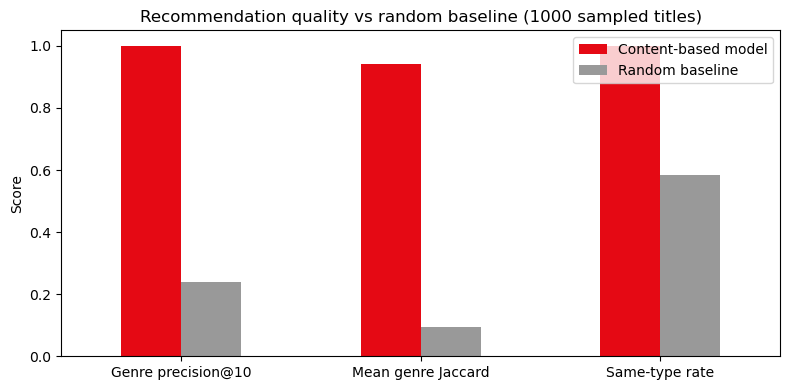

In [ ]:
res.plot(kind="bar", figsize=(8, 4), color=["#e50914", "#999999"])
plt.title("Recommendation quality vs random baseline (1000 sampled titles)")
plt.ylabel("Score"); plt.xticks(rotation=0); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()